#Telecom Customer Churn Prediction using Artificial Neural Networks

## Project Overview

This project predicts telecom customer churn using feed-forward neural networks.

The objective was to identify customers at high risk of churn and understand the business factors contributing to customer churn/ attrition.

## Key Highlights

- Performed EDA and feature engineering
- Built 2 ANN models for comparison
- Tuned classification thresholds for churn detection
- Compared model complexity vs performance for business impact
- Identified key churn-driving customer behaviors

## Business Impact

The model can help telecom companies:

- identify high-risk customers
- improve retention campaigns
- reduce customer acquisition costs
- prioritize proactive support interventions

## Workflow

1. Business Problem
2. Data Loading
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Preprocessing
7. Model Building
8. Threshold Optimization
9. Model Comparison
10. Business Insights
11. Final Recommendations

#Loading the dataset


In [173]:
import pandas as pd

url = "https://raw.githubusercontent.com/GodOfWRaTH4848/Telecom-Customer-Churn-Prediction/refs/heads/main/data/telco_churn.csv"

df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [174]:
df.shape

(7043, 21)

#A) Data Exploration and Preparation

In [175]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


##Exploratory Data Analysis

Checking for attributes and their values with and without nulls

In [176]:
summary_raw = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null_count': df.count(),
    'null_count': df.isnull().sum(),
    'null_percentage': (df.isnull().sum() / len(df)) * 100,
    'distinct_count': df.nunique()
})

print(summary_raw)


                    dtype  non_null_count  null_count  null_percentage  \
customerID         object            7043           0              0.0   
gender             object            7043           0              0.0   
SeniorCitizen       int64            7043           0              0.0   
Partner            object            7043           0              0.0   
Dependents         object            7043           0              0.0   
tenure              int64            7043           0              0.0   
PhoneService       object            7043           0              0.0   
MultipleLines      object            7043           0              0.0   
InternetService    object            7043           0              0.0   
OnlineSecurity     object            7043           0              0.0   
OnlineBackup       object            7043           0              0.0   
DeviceProtection   object            7043           0              0.0   
TechSupport        object            7

In [177]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(),
    errors='coerce'
)

In [178]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [179]:
# Checks for data inconsistencies
numerical_cols=[]
categorical_columns = []
for col in df.columns:
  if df[col].dtype!='object':
    print(col)
    print(df[col].min(), df[col].max())
    numerical_cols.append(col)
  else:
    categorical_columns.append(col)

SeniorCitizen
0 1
tenure
0 72
MonthlyCharges
18.25 118.75
TotalCharges
18.8 8684.8


### Data Quality Summary

- No major inconsistencies found in categorical features
- Minimal missing values
- `TotalCharges` required datatype correction and had 11 nulls
- Data was sufficiently clean for modeling after preprocessing

##Data Preprocessing

In [180]:
cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies','PhoneService','PaperlessBilling','Churn']

for col in cols:
    df[col] = df[col].replace({'No internet service': 'No'})

df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})


for col in cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['MultipleLines'] = df['MultipleLines'].map({'Yes': 1, 'No': 0})


In [181]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

- Boolean values converted to 0s and 1s

- Gender male, female converted to 1,0

## Univariate and Bivariate analysis

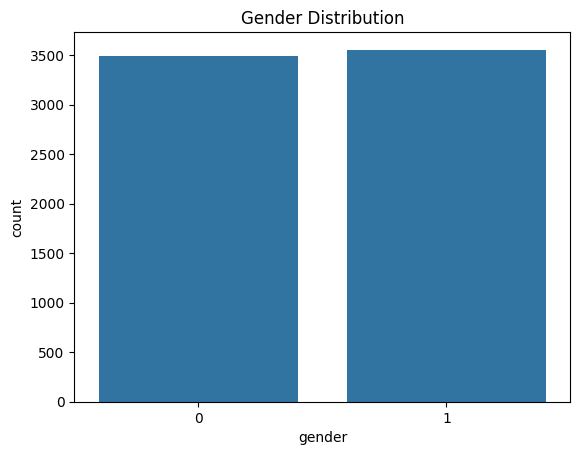

In [182]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()

In [183]:
pd.crosstab(df['gender'], df['Churn'])

Churn,0,1
gender,,
0,2549,939
1,2625,930


Gender distribution is nearly balanced across the dataset, with an approximately 50-50 split.

Churn patterns do not appear to differ significantly based on gender alone, suggesting that gender is likely not a strong driver of customer churn. More influential factors should be explored to identify the root causes of churn.

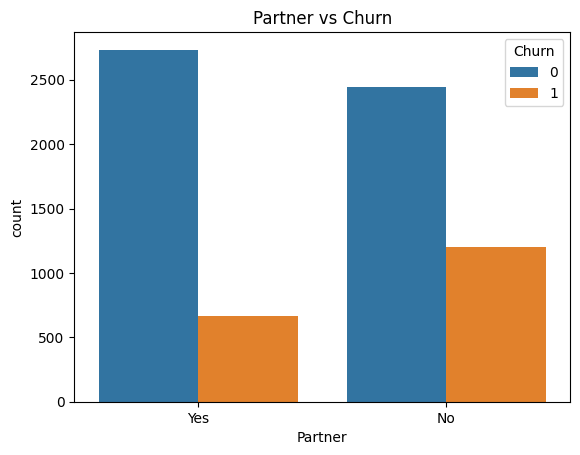

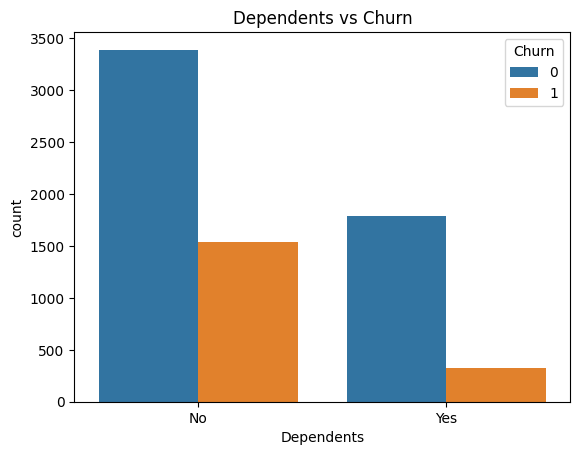

In [184]:
sns.countplot(x='Partner', hue='Churn', data=df)
plt.title('Partner vs Churn')
plt.show()

sns.countplot(x='Dependents', hue='Churn', data=df)
plt.title('Dependents vs Churn')
plt.show()

Customers without partner and dependents contributed to higher churn rates.

This may indicate lower long-term service dependency and reduced switching friction.

Retention campaigns could prioritize these customer groups.

### New 'Family' feature

In [185]:
cols = ['Partner','Dependents']

for col in cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})


df['Family'] = ((df['Partner'] + df['Dependents']) > 0).astype(int)


Since No Partner and No dependants have a similar churn signal, making a new feature called `Family` that will combine both Partner and Dependants into 1 feature

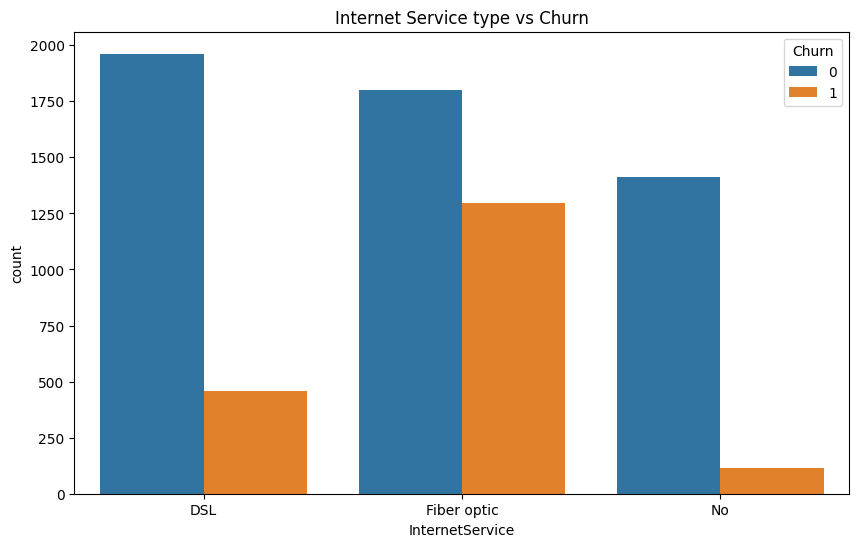

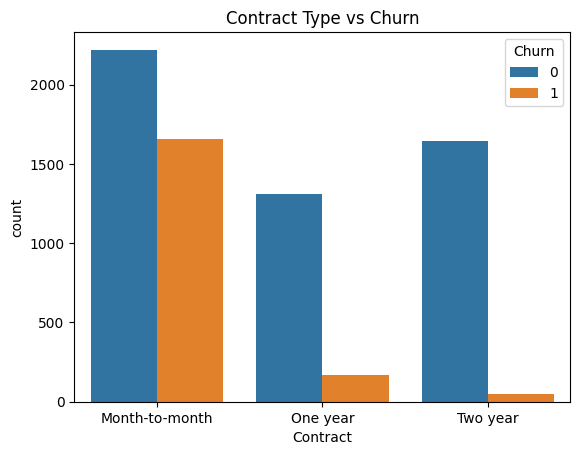

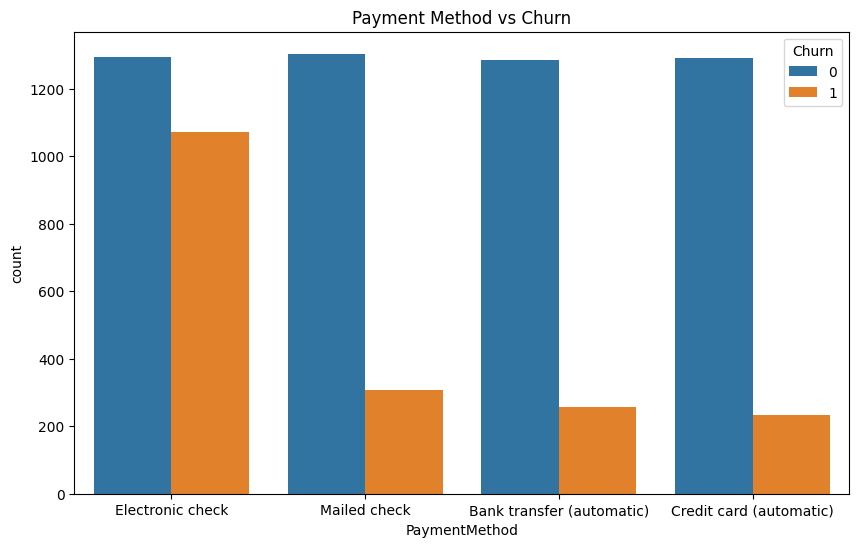

In [186]:
plt.figure(figsize=(10, 6))

sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Internet Service type vs Churn')
plt.show()

sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Payment Method vs Churn')
plt.show()


**Observation** Month to Month duration, Fiber optic service and Electronic payment type have the highest Churn

##Encoding

In [187]:
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)

In [188]:
df = df.astype({col: 'int' for col in df.columns if df[col].dtype == 'bool'})

##Correlation Analysis

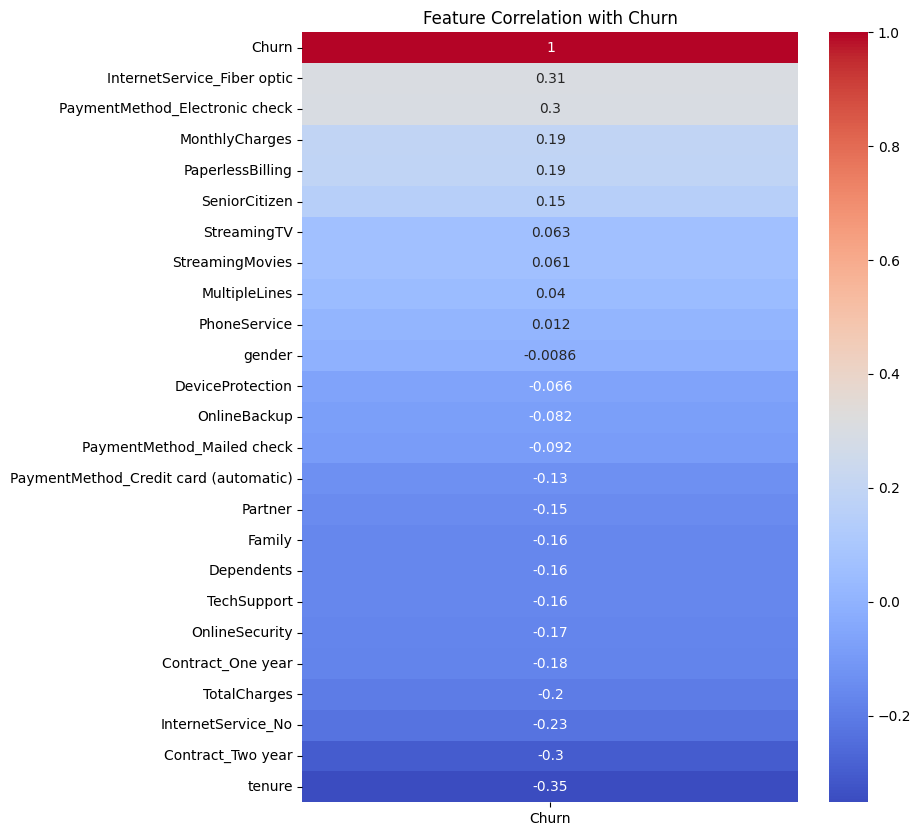

In [189]:
plt.figure(figsize=(8, 10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr[['Churn']].sort_values(by='Churn', ascending=False),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation with Churn')
plt.show()

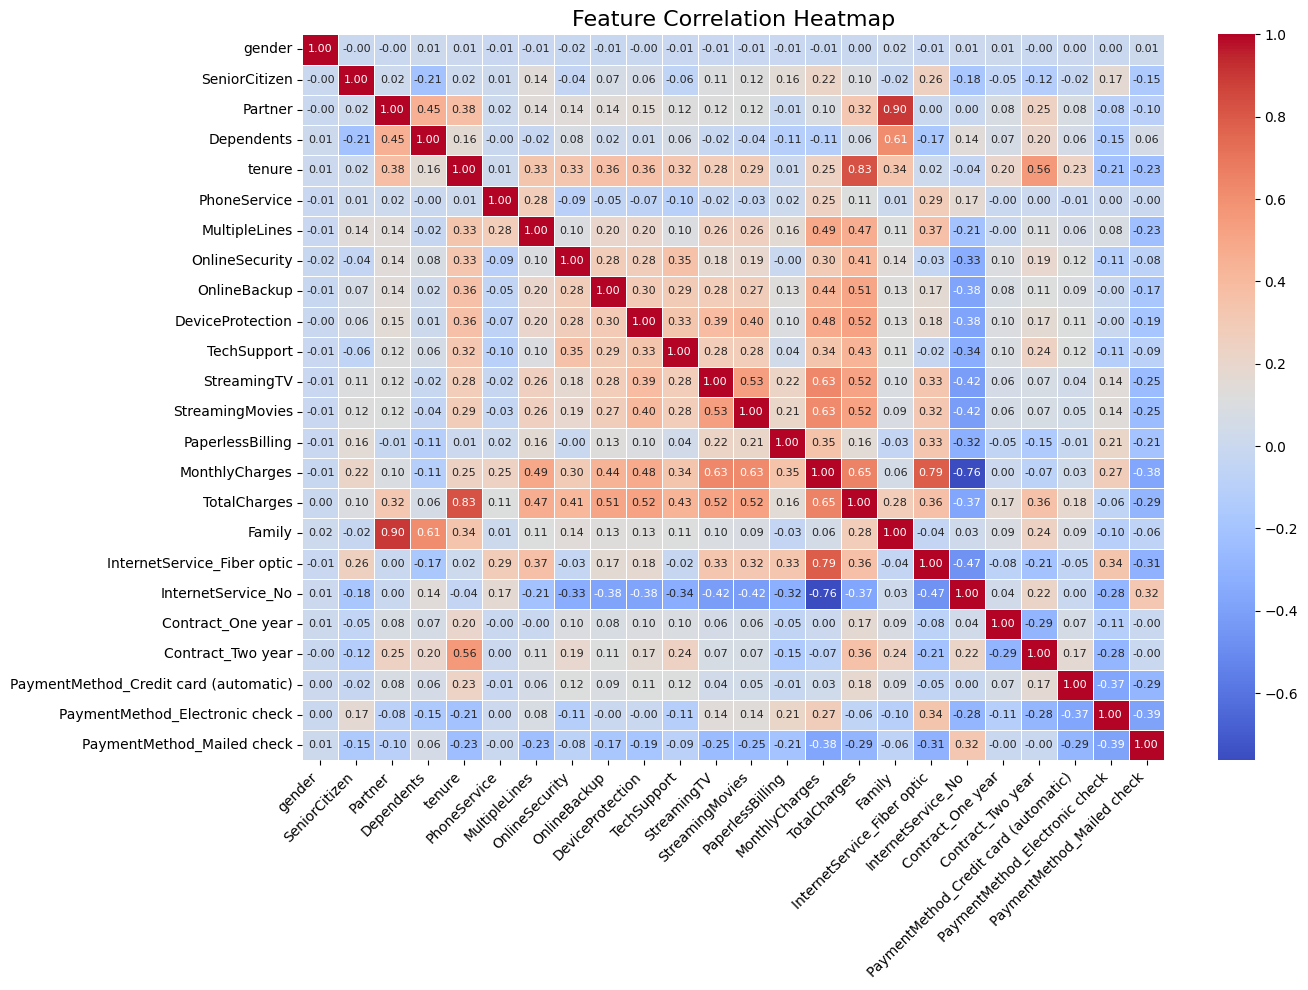

In [190]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

# Remove target variable
corr_no_churn = corr.drop('Churn', axis=0).drop('Churn', axis=1)

sns.heatmap(
    corr_no_churn,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={"size":8}
)

plt.title('Feature Correlation Heatmap', fontsize=16)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

###Observation

1. The engineered feature `Family` shows a stronger relationship with the target variable compared to the individual `Partner` and `Dependents` features.

2. Gender shows a very weak relationship with the target variable, indicating limited predictive value for churn prediction.

3. `TotalCharges` is highly correlated with `tenure`, suggesting possible multicollinearity between the two variables. Among them, `tenure` appears to have a stronger relationship with churn.


### Inference

- `Partner`, `Dependents`, and `Gender` may contribute limited additional predictive value and can be considered for removal during feature selection.
- Since `TotalCharges` and `tenure` are strongly related, retaining only one of them may help reduce redundancy in the model.

###Business Strategies

The analysis indicates that Fiber Optic users exhibit higher churn behavior. This suggests that factors such as service quality, pricing, customer support, or competitor offerings related to Fiber Optic services may require deeper business evaluation.

The analysis also shows that customers with lower tenure exhibit significantly higher churn behavior. This may indicate issues related to onboarding experience, perceived service value, pricing, customer expectations, or early-stage customer support.

In [191]:
df = df.drop(columns=['customerID','TotalCharges','gender','Partner','Dependents'])

##Scaling

In [192]:
from sklearn.preprocessing import StandardScaler

num_cols = ['tenure', 'MonthlyCharges']

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

#B) Model

In [193]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [194]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert to tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

##ChurnANN model

In [195]:
class ChurnANN(nn.Module):
    def __init__(self, input_dim):
        super(ChurnANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = ChurnANN(X_train.shape[1])

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### ChurnANN Architecture

A simple feed-forward neural network architecture was implemented for binary churn classification.

The network consists of two hidden layers designed to progressively learn compressed feature representations from customer behavioral data.

- The first hidden layer contains 16 neurons with ReLU activation, enabling the model to capture non-linear relationships within the dataset.
- A dropout layer of 20% was introduced to reduce overfitting and improve generalization performance.
- The second hidden layer further compresses learned representations into 8 neurons using another ReLU activation layer.

The output layer consists of a single neuron with Sigmoid activation to generate churn probabilities for binary classification.

Binary Cross-Entropy was used as the loss function, while the Adam optimizer was selected for efficient gradient-based optimization during training.

###Training

In [196]:
epochs = 200
for epoch in range(epochs):

    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)


    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.6607125401496887
Epoch 10, Loss: 0.6509239077568054
Epoch 20, Loss: 0.6426220536231995
Epoch 30, Loss: 0.6355434656143188
Epoch 40, Loss: 0.6290023922920227
Epoch 50, Loss: 0.6214146614074707
Epoch 60, Loss: 0.6135883331298828
Epoch 70, Loss: 0.6036090850830078
Epoch 80, Loss: 0.5924847722053528
Epoch 90, Loss: 0.5798671245574951
Epoch 100, Loss: 0.5657752752304077
Epoch 110, Loss: 0.5504292249679565
Epoch 120, Loss: 0.5336205363273621
Epoch 130, Loss: 0.5159254670143127
Epoch 140, Loss: 0.4989721179008484
Epoch 150, Loss: 0.4866417348384857
Epoch 160, Loss: 0.47211146354675293
Epoch 170, Loss: 0.46036848425865173
Epoch 180, Loss: 0.4537883400917053
Epoch 190, Loss: 0.4487385153770447


### Evaluation and tuning

In [197]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred = (y_pred.numpy() > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88      1036
           1       0.70      0.54      0.61       373

    accuracy                           0.82      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.81      0.82      0.81      1409

[[948  88]
 [170 203]]


In [198]:
model.eval()
with torch.no_grad():
    y_prob = model(X_test_tensor).numpy() # Get the raw probabilities once

for threshold in [0.1, 0.2, 0.3, 0.4]:
    print(f"\n--- Threshold: {threshold} ---")
    y_pred = (y_prob > threshold).astype(int)
    print(classification_report(y_test, y_pred))


--- Threshold: 0.1 ---
              precision    recall  f1-score   support

           0       0.98      0.33      0.49      1036
           1       0.34      0.98      0.51       373

    accuracy                           0.50      1409
   macro avg       0.66      0.65      0.50      1409
weighted avg       0.81      0.50      0.50      1409


--- Threshold: 0.2 ---
              precision    recall  f1-score   support

           0       0.95      0.63      0.76      1036
           1       0.47      0.90      0.62       373

    accuracy                           0.70      1409
   macro avg       0.71      0.77      0.69      1409
weighted avg       0.82      0.70      0.72      1409


--- Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       0.90      0.78      0.84      1036
           1       0.56      0.77      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
we

A threshold of 0.3 was selected as the final decision boundary because it provided the best balance between churn detection recall and precision.

Lower thresholds significantly increased false positives, while higher thresholds reduced the model’s ability to identify at-risk customers.

From a business perspective, prioritizing recall is important in churn prediction, since failing to identify potential churners may result in lost revenue and customer attrition.

Although the 0.4 threshold achieved slightly higher precision, the 0.3 threshold was preferred because it captured a larger proportion of potential churn customers while maintaining acceptable precision levels.

###Evaluating Underfiting or Overfiting

In [199]:
model.eval()

with torch.no_grad():

    train_probs = model(X_train_tensor).numpy()
    test_probs = model(X_test_tensor).numpy()

threshold = 0.3
y_train_pred = (train_probs > threshold).astype(int)
y_test_pred = (test_probs > threshold).astype(int)

training=classification_report(y_train, y_train_pred)
testing=classification_report(y_test, y_test_pred)

print(f"Threshold: {threshold} \n TRAINING SET: {training} \n Testing SET: {testing}")



Threshold: 0.3 
 TRAINING SET:               precision    recall  f1-score   support

           0       0.89      0.78      0.83      4138
           1       0.54      0.74      0.63      1496

    accuracy                           0.77      5634
   macro avg       0.72      0.76      0.73      5634
weighted avg       0.80      0.77      0.78      5634
 
 Testing SET:               precision    recall  f1-score   support

           0       0.90      0.78      0.84      1036
           1       0.56      0.77      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.78      0.79      1409



### ANN Generalization Performance

Performance metrics across the training and testing datasets remained relatively aligned, suggesting that the ANN generalized reasonably well to unseen customer data.

The selected threshold of 0.3 achieved strong recall performance while maintaining acceptable precision levels, making it suitable for churn prediction scenarios where identifying at-risk customers is a higher operational priority.

The absence of a significant train-test performance gap indicates limited overfitting and stable learning behavior throughout training.

## SimpleANN

In [200]:
class SimpleANN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 14),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(14, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model2 = SimpleANN(X_train.shape[1])

criterion = nn.BCELoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001)

### SimpleANN Architecture

To evaluate whether a less complex neural network could achieve comparable performance, a simplified ANN architecture was developed and benchmarked against the previous `ChurnANN` model.

The network consists of a single hidden layer designed to learn compressed feature representations while reducing overall architectural complexity.

- The hidden layer contains 14 neurons with GELU activation, enabling smoother non-linear learning behavior and preserving partial information from negative activations.
- A dropout layer of 10% was introduced to support generalization while accounting for the reduced network size and lower parameter complexity.

The output layer consists of a single neuron with Sigmoid activation to generate churn probabilities for binary classification.

Binary Cross-Entropy was used as the loss function, while the Adam optimizer was selected for efficient gradient-based optimization during training.

###Training

In [201]:
for epoch in range(200):
    model2.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model2(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.7605060935020447
Epoch 10, Loss: 0.7284568548202515
Epoch 20, Loss: 0.6995047330856323
Epoch 30, Loss: 0.6723247170448303
Epoch 40, Loss: 0.6466637849807739
Epoch 50, Loss: 0.622343897819519
Epoch 60, Loss: 0.5985870361328125
Epoch 70, Loss: 0.576774537563324
Epoch 80, Loss: 0.5556055903434753
Epoch 90, Loss: 0.5370160341262817
Epoch 100, Loss: 0.521470844745636
Epoch 110, Loss: 0.5061362981796265
Epoch 120, Loss: 0.49303123354911804
Epoch 130, Loss: 0.48376157879829407
Epoch 140, Loss: 0.4732700288295746
Epoch 150, Loss: 0.46426844596862793
Epoch 160, Loss: 0.45711055397987366
Epoch 170, Loss: 0.45197948813438416
Epoch 180, Loss: 0.4471481144428253
Epoch 190, Loss: 0.4448884427547455


### Evaluating and tuning

In [202]:
model2.eval()
with torch.no_grad():
    y_prob = model2(X_test_tensor).numpy() # Get the raw probabilities once

for threshold in [0.1, 0.2, 0.3, 0.4]:
    print(f"\n--- Threshold: {threshold} ---")
    y_pred = (y_prob > threshold).astype(int)
    print(classification_report(y_test, y_pred))


--- Threshold: 0.1 ---
              precision    recall  f1-score   support

           0       0.98      0.37      0.54      1036
           1       0.36      0.98      0.53       373

    accuracy                           0.53      1409
   macro avg       0.67      0.68      0.53      1409
weighted avg       0.82      0.53      0.53      1409


--- Threshold: 0.2 ---
              precision    recall  f1-score   support

           0       0.93      0.63      0.75      1036
           1       0.46      0.87      0.60       373

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.70      0.71      1409


--- Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1036
           1       0.54      0.80      0.64       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
we

### Threshold Selection

Multiple decision thresholds were evaluated to balance churn detection capability and prediction reliability.

Although lower thresholds improved recall performance, they also introduced a significant increase in false positives. A threshold of 0.4 was ultimately selected because it provided the strongest balance between precision, recall, F1 score, and overall model stability.

Compared to lower thresholds, the selected threshold produced more reliable churn predictions while maintaining acceptable churn detection performance.

In [203]:
model2.eval()

with torch.no_grad():

    train_probs = model2(X_train_tensor).numpy()
    test_probs = model2(X_test_tensor).numpy()

threshold = 0.4
y_train_pred = (train_probs > threshold).astype(int)
y_test_pred = (test_probs > threshold).astype(int)

training=classification_report(y_train, y_train_pred)
testing=classification_report(y_test, y_test_pred)

print(f"Threshold: {threshold} \n TRAINING SET: {training} \n Testing SET: {testing}")

Threshold: 0.4 
 TRAINING SET:               precision    recall  f1-score   support

           0       0.86      0.84      0.85      4138
           1       0.58      0.62      0.60      1496

    accuracy                           0.78      5634
   macro avg       0.72      0.73      0.73      5634
weighted avg       0.79      0.78      0.78      5634
 
 Testing SET:               precision    recall  f1-score   support

           0       0.89      0.85      0.87      1036
           1       0.63      0.69      0.66       373

    accuracy                           0.81      1409
   macro avg       0.76      0.77      0.76      1409
weighted avg       0.82      0.81      0.81      1409



Similar performance as ChurnANN. No indication of overfitting

In [204]:
# Model 1 predictions
model.eval()
y_pred1 = (model(X_test_tensor).detach().numpy() > 0.3).astype(int)

# Model 2 predictions
model2.eval()
y_pred2 = (model2(X_test_tensor).detach().numpy() > 0.4).astype(int)

print("Model 1: ChurnANN (Complex) ")
print(classification_report(y_test, y_pred1))

print("Model 2: SimpleANN (Simple)")
print(classification_report(y_test, y_pred2))

Model 1: ChurnANN (Complex) 
              precision    recall  f1-score   support

           0       0.90      0.78      0.84      1036
           1       0.56      0.77      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.78      0.79      1409

Model 2: SimpleANN (Simple)
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1036
           1       0.63      0.69      0.66       373

    accuracy                           0.81      1409
   macro avg       0.76      0.77      0.76      1409
weighted avg       0.82      0.81      0.81      1409



#C) Observation

The simplified ANN achieved performance comparable to the more complex architecture despite having significantly lower model complexity.

Given the relatively limited feature engineering and absence of strong feature correlations within the dataset, the smaller architecture appeared sufficient for learning underlying churn patterns effectively.

From a business and deployment perspective, the simpler model offers advantages in computational efficiency, maintainability, and operational practicality while maintaining competitive predictive performance.

## Model Comparison Observation

Both ANN architectures achieved relatively similar predictive performance on the test dataset.

Although the more complex `ChurnANN` model achieved slightly higher recall, the simplified `SimpleANN` architecture produced comparable overall performance while improving accuracy and reducing architectural complexity.

From a deployment perspective, the simpler model may represent a more practical solution due to:
- lower computational overhead
- reduced model complexity
- easier maintainability
- improved operational efficiency

These results suggest that a lightweight ANN architecture may be sufficient for modeling churn behavior within this dataset.

#D) Summarising the findings

In [205]:
probs = model(X_test_tensor).detach().numpy()

high_risk = X_test[probs.flatten() > 0.5]

comparison_df = pd.DataFrame({

    'Overall Mean': X_test.mean(),

    'High Risk Mean': high_risk.mean()

})

comparison_df['Difference'] = (
    comparison_df['High Risk Mean']
    - comparison_df['Overall Mean']
)

comparison_df.sort_values(
    by='Difference',
    ascending=False
)

,Overall Mean,High Risk Mean,Difference
MonthlyCharges,-0.013630,0.601970,0.615600
InternetService_Fiber optic,0.436480,0.938144,0.501665
PaymentMethod_Electronic check,0.339248,0.807560,0.468312
PaperlessBilling,0.600426,0.817869,0.217444
SeniorCitizen,0.167495,0.340206,0.172712
StreamingMovies,0.379702,0.498282,0.118580
StreamingTV,0.373314,0.474227,0.100912
MultipleLines,0.407381,0.481100,0.073719
PhoneService,0.907736,0.975945,0.068209
DeviceProtection,0.348474,0.216495,-0.131979


In [206]:
probs = model2(X_test_tensor).detach().numpy()

high_risk = X_test[probs.flatten() > 0.5]

comparison_df = pd.DataFrame({

    'Overall Mean': X_test.mean(),

    'High Risk Mean': high_risk.mean()

})

comparison_df['Difference'] = (
    comparison_df['High Risk Mean']
    - comparison_df['Overall Mean']
)

comparison_df.sort_values(
    by='Difference',
    ascending=False
)

,Overall Mean,High Risk Mean,Difference
MonthlyCharges,-0.013630,0.568914,0.582544
InternetService_Fiber optic,0.436480,0.933333,0.496854
PaymentMethod_Electronic check,0.339248,0.800000,0.460752
PaperlessBilling,0.600426,0.782456,0.182030
SeniorCitizen,0.167495,0.312281,0.144786
StreamingMovies,0.379702,0.466667,0.086965
PhoneService,0.907736,0.982456,0.074720
MultipleLines,0.407381,0.470175,0.062794
StreamingTV,0.373314,0.421053,0.047738
DeviceProtection,0.348474,0.214035,-0.134439


#E) Final Results & Business Recommendations

## Churn Pattern Consistency Across Architectures

Both ANN architectures identified highly similar customer behavior patterns associated with elevated churn risk.

Across both models, high-risk customers consistently demonstrated:
- shorter tenure
- higher monthly charges
- increased usage of fiber optic internet services
- greater reliance on electronic check payment methods

Conversely, customers with:
- long-term contracts
- technical support services
- online security features
- online backup services

were consistently underrepresented among predicted churn-risk groups.

The similarity in learned churn patterns further supports the conclusion that the simplified ANN architecture was sufficient for modeling customer churn behavior within this dataset.

#F) Business Recommendations

Both ANN architectures identified highly similar churn patterns, strengthening confidence in the observed customer behavior trends and supporting consistent business recommendations.

## Customer Retention & Early Engagement

Customers with lower tenure demonstrated significantly higher churn representation, suggesting that newer customers are more vulnerable to early attrition and may not yet be fully integrated into the telecom ecosystem.

To address this:
- early-stage retention campaigns should be prioritized
- onboarding workflows should be improved
- customer engagement initiatives should focus on increasing long-term service adoption during the initial customer lifecycle period

## Service Bundling & Ecosystem Integration

Customers utilizing additional support-oriented services such as:
- Online Backup
- Device Protection
- Online Security
- Tech Support

showed substantially lower churn representation.

This may indicate that customers more deeply integrated into value-added telecom services experience:
- higher perceived service value
- greater service dependency
- stronger long-term retention behavior

Bundled service offerings and onboarding incentives for support-related services may therefore improve customer retention outcomes.

## Pricing & Package Optimization

Higher monthly charges were strongly associated with elevated churn risk.

This suggests that pricing structure, perceived value, and competitor offerings may influence customer retention decisions.

Potential business actions include:
- reviewing pricing competitiveness
- introducing loyalty-based pricing incentives
- developing bundled service packages
- designing upgrade-oriented pricing strategies to improve perceived customer value

## Payment & Billing Experience Analysis

Electronic check payment methods and paperless billing demonstrated strong association with elevated churn risk.

This may suggest that customers using more flexible or digitally transactional payment behaviors exhibit lower long-term commitment and reduced switching friction.

The findings may also warrant further investigation into:
- payment experience quality
- billing transparency
- customer satisfaction within digital payment channels

## Fiber Optic Service Evaluation

Fiber optic internet customers showed significantly higher churn representation compared to the overall customer population.

This may indicate potential concerns related to:
- pricing expectations
- service quality perception
- customer support experience
- value-for-money considerations

Further analysis of customer satisfaction and competitor positioning within fiber optic services may help improve retention performance while supporting broader adoption of higher-tier internet offerings.